In [ ]:
import matplotlib 
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import numpy as np

output: pd.DataFrame = pd.read_csv('../outputs/siamese_test_701383/test_triplets_predictions.csv')

In [6]:
output.head(10)

,anchor_path,pos_path,neg_path,d_ap,d_an,delta
0,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165608.jpg,./data/drive/id_502/IMG_20251025_183406680.jpg,0.077976,0.248725,0.170750
1,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165619.jpg,./data/drive/id_106/IMG_20251020_141624_BURST1...,0.134851,0.433503,0.298651
2,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165626.jpg,./data/drive/id_501/IMG_3893.jpg,0.098431,0.251357,0.152926
3,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165633.jpg,./data/drive/id_502/IMG_20251025_183502583.jpg,0.139836,0.146112,0.006276
4,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165639.jpg,./data/drive/id_502/IMG_20251025_183356129.jpg,0.133705,0.266675,0.132970
5,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165644.jpg,./data/drive/id_501/IMG_3884(1).jpg,0.142595,0.630674,0.488079
6,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165650.jpg,./data/drive/id_502/IMG_20251025_183532793.jpg,0.171143,0.203132,0.031989
7,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165654.jpg,./data/drive/id_106/IMG_20251020_141630_BURST1...,0.140616,0.253514,0.112899
8,./data/drive/id_100/20251105_165600.jpg,./data/drive/id_100/20251105_165659.jpg,./data/drive/id_502/IMG_20251025_183403609.jpg,0.128774,0.240256,0.111482
9,./data/drive/id_100/20251105_165608.jpg,./data/drive/id_100/20251105_165619.jpg,./data/drive/id_103/IMG_4794.jpg,0.105804,0.782192,0.676388


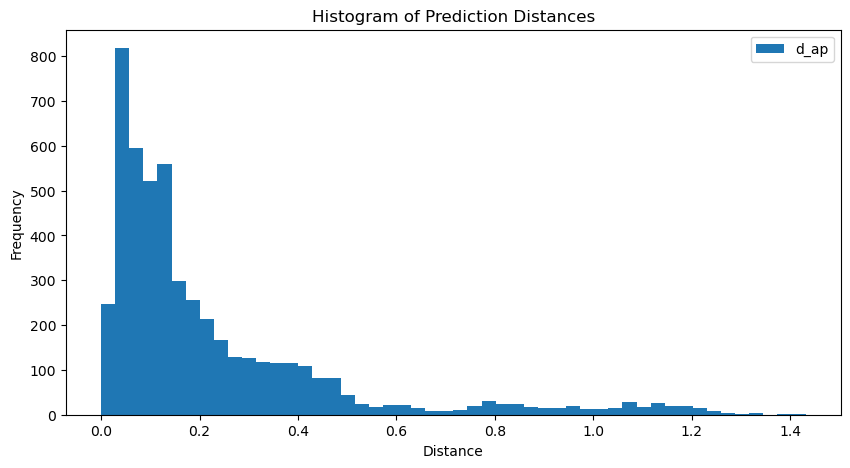

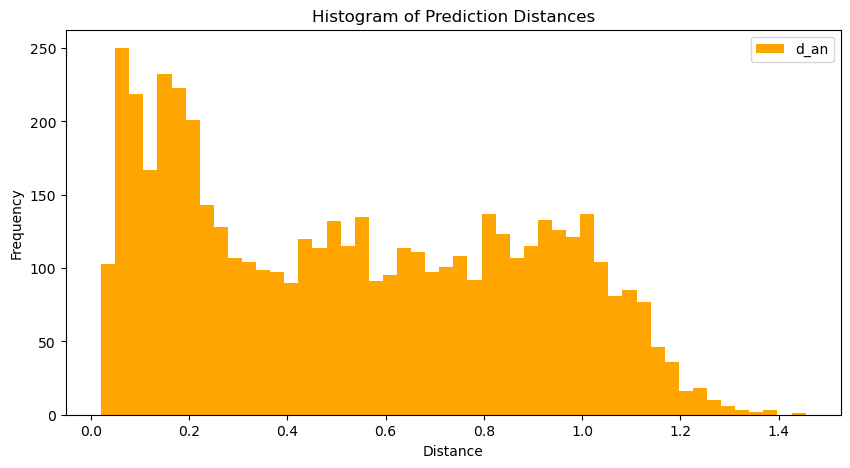

In [4]:
# plot histogram of the prediction scores in two different figures
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(output['d_ap'], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Distances')
plt.legend(['d_ap', 'd_an'])
plt.show()

plt.figure(figsize=(10,5))
plt.hist(output['d_an'], bins=50, color='orange')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Distances')
plt.legend(['d_an'])
plt.show()

In [5]:
# add a column specifying if the score is relevant or not 
# for d_ap, relevant if distance < 0.5
# for d_an, relevant if distance > 0.5
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import numpy as np
true_labels = np.concatenate((np.ones(len(output)), np.zeros(len(output))))
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
        prediction = np.concatenate(((output['d_ap'].values < threshold).astype(int), (1 - (output['d_an'].values > threshold)).astype(int)))
        accuracy = accuracy_score(true_labels, prediction)
        precision = precision_score(true_labels, prediction)
        recall = recall_score(true_labels, prediction)
        f1 = f1_score(true_labels, prediction)
        print(f'Threshold {threshold}: Overall - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}')


Threshold 0.3: Overall - Accuracy: 0.7090, Precision: 0.6885, Recall: 0.7632, F1-score: 0.7239
Threshold 0.4: Overall - Accuracy: 0.7158, Precision: 0.6721, Recall: 0.8428, F1-score: 0.7478
Threshold 0.5: Overall - Accuracy: 0.7055, Precision: 0.6477, Recall: 0.9013, F1-score: 0.7537
Threshold 0.6: Overall - Accuracy: 0.6743, Precision: 0.6172, Recall: 0.9180, F1-score: 0.7381
Threshold 0.7: Overall - Accuracy: 0.6424, Precision: 0.5906, Recall: 0.9277, F1-score: 0.7218


In [4]:
output_contrastive = pd.read_csv('../outputs/siamese_train_674729/val_pair_predictions.csv')


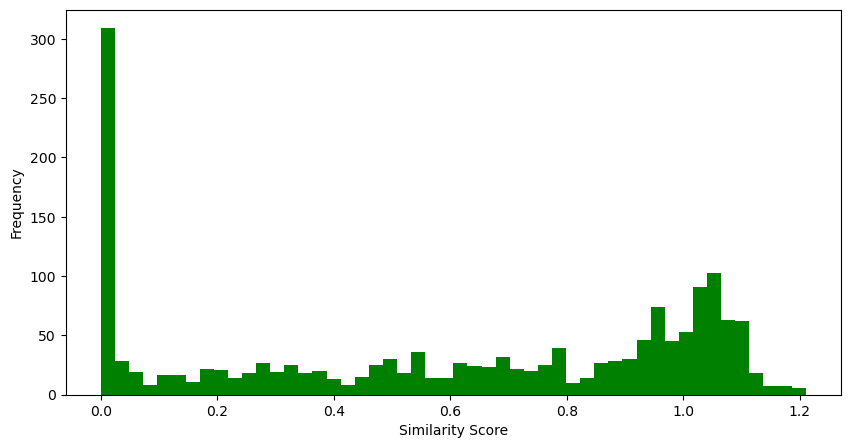

In [9]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(output_contrastive['distance'], bins=50, color='green')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.show()

In [11]:
accuracy = accuracy_score(output_contrastive['label_true'], 1*(output_contrastive['distance'] < 0.6))
accuracy

0.8694344163658243